In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [50]:
data.shape

(1338, 7)

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [52]:
data=pd.get_dummies(data)
data.head()


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [53]:
rem=['sex_female','smoker_no','region_northeast']
data=data.drop(columns=rem)
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [54]:
data['charge']=data['charges']
data.drop('charges',1,inplace=True)

/home/varaprasad/miniconda3/envs/tensor/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  


In [55]:
data.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,charge
0,19,27.900,0,0,1,0,0,1,16884.92400
1,18,33.770,1,1,0,0,1,0,1725.55230
2,28,33.000,3,1,0,0,1,0,4449.46200
3,33,22.705,0,1,0,1,0,0,21984.47061
4,32,28.880,0,1,0,1,0,0,3866.85520


In [56]:
data.shape

(1338, 9)

<AxesSubplot:>

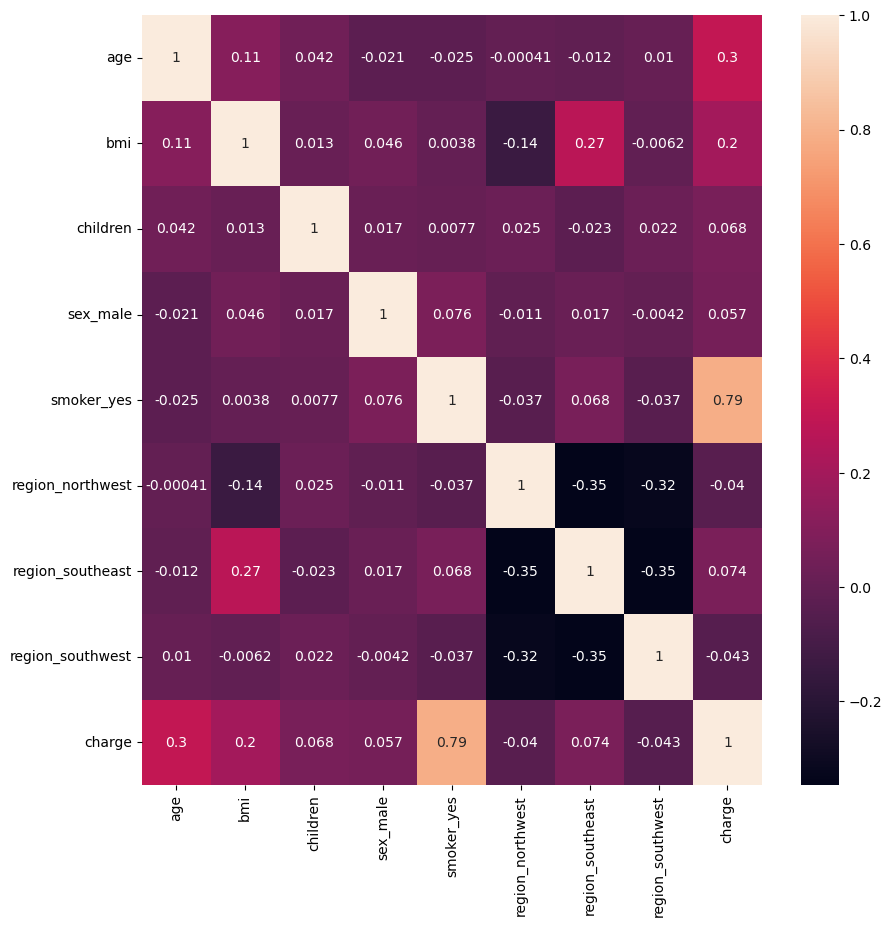

In [57]:
cor=data.corr()
import seaborn as sns
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(10,10))
sns.heatmap(cor,annot=True)

In [58]:
x=data.iloc[:,:5]
y=data['charge']
x.head()

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0


In [59]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charge, dtype: float64

In [60]:
n=x.shape[0]
n

1338

In [19]:
x_train,x_test=np.split(x,[int(n*0.70)])
y_train,y_test=np.split(y,[int(n*0.70)])
x_train.shape

(936, 5)

In [63]:
from sklearn.preprocessing import MinMaxScaler
mms1=MinMaxScaler()
mms2=MinMaxScaler()
x_train_norm=mms1.fit_transform(x_train)
x_test_norm=mms2.fit_transform(x_test)

In [64]:
x_train_norm

array([[0.02173913, 0.34689134, 0.        , 0.        , 1.        ],
       [0.        , 0.51743173, 0.2       , 1.        , 0.        ],
       [0.2173913 , 0.49506101, 0.6       , 1.        , 0.        ],
       ...,
       [0.58695652, 0.56188263, 0.        , 0.        , 0.        ],
       [0.30434783, 0.61650203, 0.4       , 1.        , 0.        ],
       [0.89130435, 0.33527019, 0.        , 0.        , 0.        ]])

In [65]:
x_test_norm

array([[0.56521739, 0.35577585, 0.4       , 1.        , 0.        ],
       [0.45652174, 0.20404791, 1.        , 0.        , 0.        ],
       [0.        , 0.25788242, 0.4       , 1.        , 0.        ],
       ...,
       [0.        , 0.5517004 , 0.        , 0.        , 0.        ],
       [0.06521739, 0.24741842, 0.        , 0.        , 0.        ],
       [0.93478261, 0.33746386, 0.        , 0.        , 1.        ]])

In [2]:
import keras
from tensorflow.keras.layers import Dense,ReLU
from tensorflow.keras.models import Sequential
import tensorflow as tf

2023-12-13 20:20:02.947023: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


In [86]:
model=Sequential()
model.add(Dense(units=8,kernel_initializer='he_normal',activation='relu',input_dim=5)) #input layer and hidden layer
model.add(Dense(units=7,kernel_initializer='he_normal',activation='relu'))
model.add(Dense(units=6,kernel_initializer='he_normal',activation='relu'))
model.add(Dense(units=1,kernel_initializer='glorot_uniform',activation='linear')) #output layer
optimizer = tf.keras.optimizers.Adam(learning_rate=1)

model.compile(optimizer=optimizer,loss='mean_squared_error',metrics=['mean_squared_error','mean_absolute_error'])

In [87]:
model.fit(x_train_norm,y_train,batch_size=50,epochs=200,validation_split=0.20)

Epoch 1/200
15/15 [==============================] - 0s 10ms/step - loss: 263755590.0000 - mean_squared_error: 263755590.0000 - mean_absolute_error: 11937.6055 - val_loss: 145980304.0000 - val_mean_squared_error: 145980304.0000 - val_mean_absolute_error: 7942.9561
Epoch 2/200
15/15 [==============================] - 0s 4ms/step - loss: 116183159.0000 - mean_squared_error: 116183160.0000 - mean_absolute_error: 7546.8391 - val_loss: 36180276.0000 - val_mean_squared_error: 36180276.0000 - val_mean_absolute_error: 4073.7668
Epoch 3/200
15/15 [==============================] - 0s 4ms/step - loss: 52065242.7500 - mean_squared_error: 52065241.7500 - mean_absolute_error: 4738.7639 - val_loss: 32152222.0000 - val_mean_squared_error: 32152222.0000 - val_mean_absolute_error: 4146.4087
Epoch 4/200
15/15 [==============================] - 0s 4ms/step - loss: 40413669.0000 - mean_squared_error: 40413669.0000 - mean_absolute_error: 4418.3116 - val_loss: 28319450.0000 - val_mean_squared_error: 2831945

In [88]:
y_pred=model.predict(x_test_norm)
from sklearn.metrics import r2_score
print(r2_score(y_pred,y_test))

0.7967094286151565


In [9]:
data=pd.read_csv('Salary_dataset.csv')
data.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [10]:
data.drop('Unnamed: 0',axis=1,inplace=True)
data.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [12]:
x=data.iloc[:,0]
y=data.iloc[:,1]

In [18]:
x

0      1.2
1      1.4
2      1.6
3      2.1
4      2.3
5      3.0
6      3.1
7      3.3
8      3.3
9      3.8
10     4.0
11     4.1
12     4.1
13     4.2
14     4.6
15     5.0
16     5.2
17     5.4
18     6.0
19     6.1
20     6.9
21     7.2
22     8.0
23     8.3
24     8.8
25     9.1
26     9.6
27     9.7
28    10.4
29    10.6
Name: YearsExperience, dtype: float64

In [19]:
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [20]:
model=Sequential()
model.add(Dense(units=2,kernel_initializer='he_normal',activation='relu',input_dim=1)) #input layer and hidden layer

model.add(Dense(units=1,kernel_initializer='glorot_uniform',activation='linear')) #output layer
optimizer = tf.keras.optimizers.Adam(learning_rate=1)

model.compile(optimizer=optimizer,loss='mean_squared_error',metrics=['mean_squared_error','mean_absolute_error'])

In [22]:
model.fit(x,y,validation_split=0.2,batch_size=5,epochs=50)

Epoch 1/50
5/5 [==============================] - 0s 29ms/step - loss: 39434396.0000 - mean_squared_error: 39434396.0000 - mean_absolute_error: 5386.1318 - val_loss: 91223328.0000 - val_mean_squared_error: 91223328.0000 - val_mean_absolute_error: 9103.8281
Epoch 2/50
5/5 [==============================] - 0s 9ms/step - loss: 39155652.0000 - mean_squared_error: 39155652.0000 - mean_absolute_error: 5370.1660 - val_loss: 97684712.0000 - val_mean_squared_error: 97684712.0000 - val_mean_absolute_error: 9449.8330
Epoch 3/50
5/5 [==============================] - 0s 8ms/step - loss: 38825868.0000 - mean_squared_error: 38825872.0000 - mean_absolute_error: 5350.8706 - val_loss: 98371224.0000 - val_mean_squared_error: 98371224.0000 - val_mean_absolute_error: 9486.5049
Epoch 4/50
5/5 [==============================] - 0s 8ms/step - loss: 38915292.0000 - mean_squared_error: 38915292.0000 - mean_absolute_error: 5360.9780 - val_loss: 98236040.0000 - val_mean_squared_error: 98236040.0000 - val_mean_a